   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day   bmi  \
0         7.7                  6.8                        6.1  33.4   
1         5.7                  6.5                        5.8  23.8   
2         8.5                  7.4                        9.1  24.1   
3         4.6                  7.0                        9.2  26.6   
4         5.7                  6.2                        5.1  28.8   

   waist_to_hip_ratio  systolic_bp  ...  gender  ethnicity  education_level  \
0            

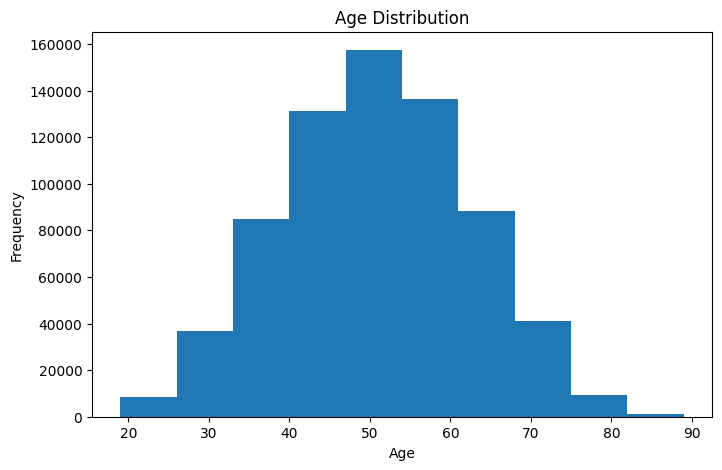

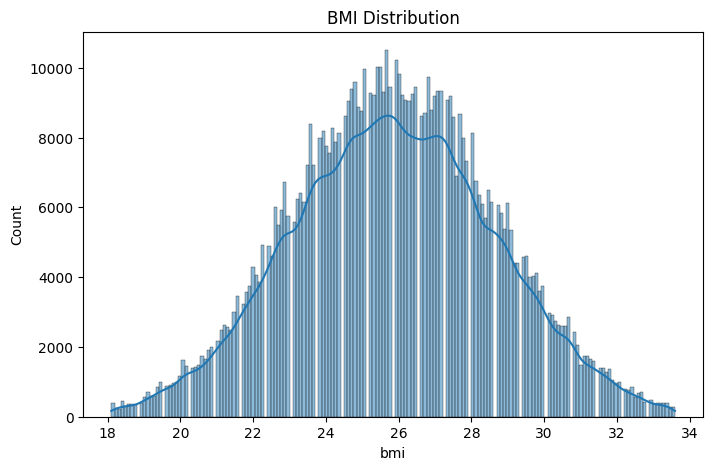

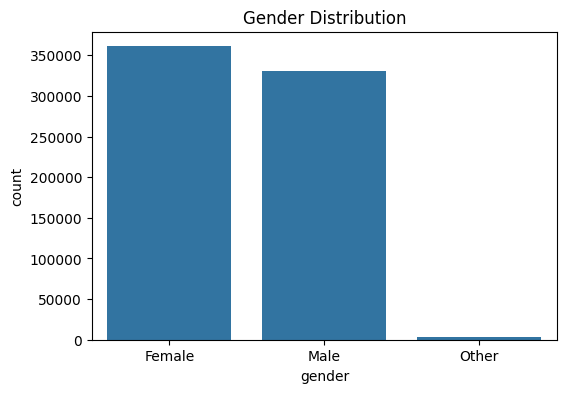

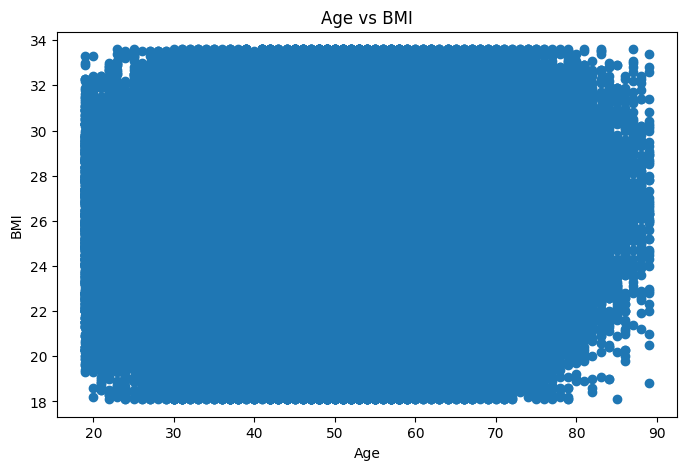

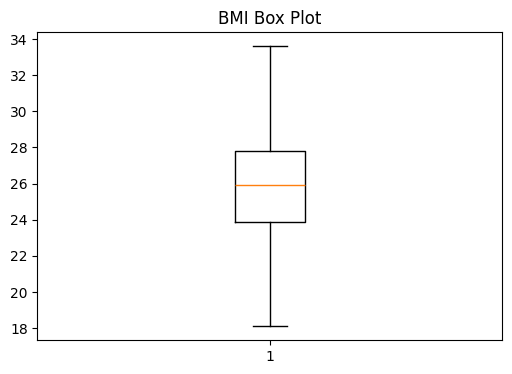

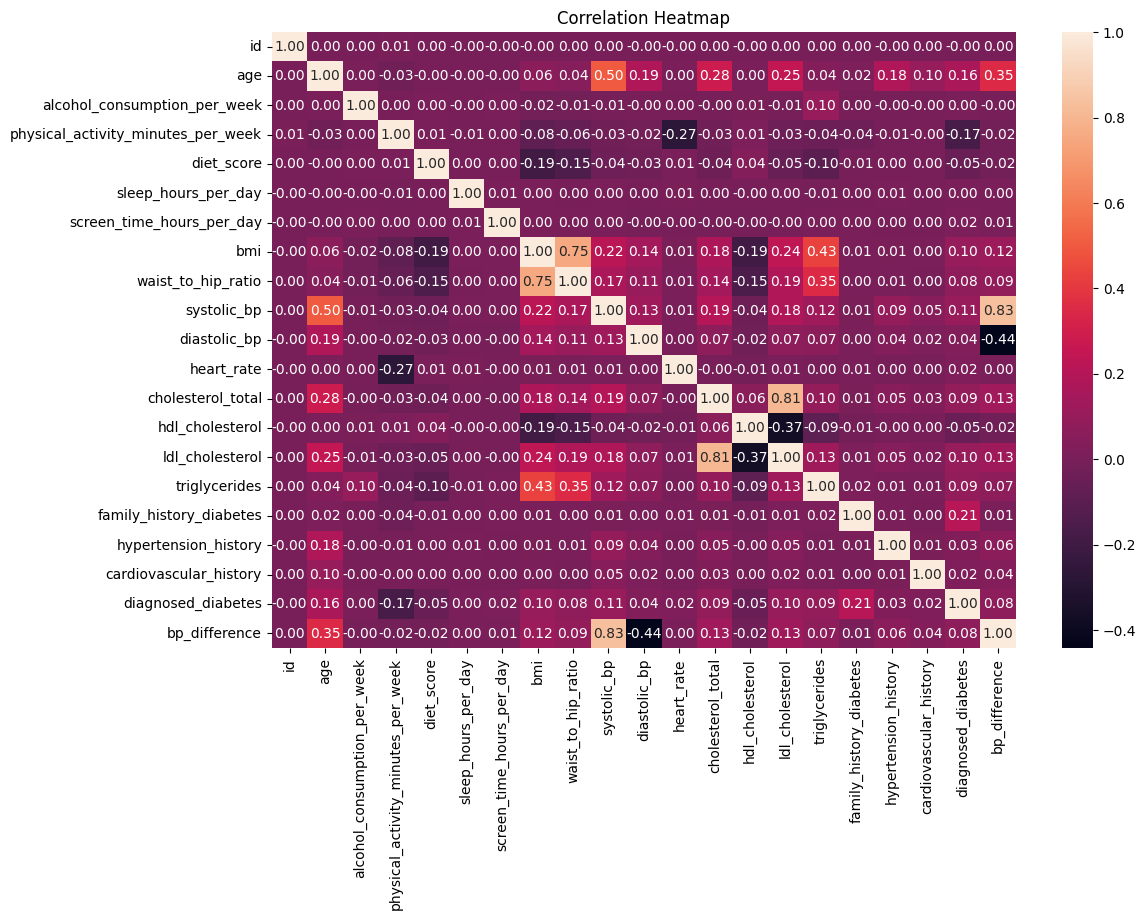

Project Completed Successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart_disease.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

print(df.isnull().sum())

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["bmi"] >= lower) &
    (df["bmi"] <= upper)
]

df["bp_difference"] = (
    df["systolic_bp"] -
    df["diastolic_bp"]
)

print("Average Age:", df["age"].mean())
print("Average BMI:", df["bmi"].mean())
print("Maximum Cholesterol:", df["cholesterol_total"].max())
print("Minimum Heart Rate:", df["heart_rate"].min())

print(df["diagnosed_diabetes"].value_counts())
print(df["gender"].value_counts())
print(df["smoking_status"].value_counts())

print(
    df.groupby("gender")["bmi"].mean()
)

print(
    df.groupby("diagnosed_diabetes")["age"].mean()
)

plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)
plt.title("BMI Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["bmi"])
plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(df["bmi"])
plt.title("BMI Box Plot")
plt.show()

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

df.to_csv(
    "data/cleaned_heart_disease.csv",
    index=False
)

print("Project Completed Successfully")

